In [34]:
import pandas as pd

df = pd.read_excel("Afficionado Coffee Roasters.xlsx")

df.head()

,transaction_id,year,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,2025,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,2025,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,2025,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,2025,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,2025,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


In [35]:
import pandas as pd

df = pd.read_excel("Afficionado Coffee Roasters.xlsx")

In [36]:
print("Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nInfo:")
print(df.info())

Shape:
(149116, 11)

Columns:
Index(['transaction_id', 'year', 'transaction_time', 'transaction_qty',
       'store_id', 'store_location', 'product_id', 'unit_price',
       'product_category', 'product_type', 'product_detail'],
      dtype='str')

Info:
<class 'pandas.DataFrame'>
RangeIndex: 149116 entries, 0 to 149115
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   transaction_id    149116 non-null  int64  
 1   year              149116 non-null  int64  
 2   transaction_time  149116 non-null  object 
 3   transaction_qty   149116 non-null  int64  
 4   store_id          149116 non-null  int64  
 5   store_location    149116 non-null  str    
 6   product_id        149116 non-null  int64  
 7   unit_price        149116 non-null  float64
 8   product_category  149116 non-null  str    
 9   product_type      149116 non-null  str    
 10  product_detail    149116 non-null  str    
dtypes: float64(1), i

In [37]:
df.isnull().sum()
df.head()

,transaction_id,year,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,2025,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,2025,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,2025,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,2025,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,2025,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


In [38]:
df["revenue"] = df["transaction_qty"] * df["unit_price"]
df.head()

store_revenue = df.groupby("store_location")["revenue"].sum()
store_revenue

store_location
Astoria            232243.91
Hell's Kitchen     236511.17
Lower Manhattan    230057.25
Name: revenue, dtype: float64

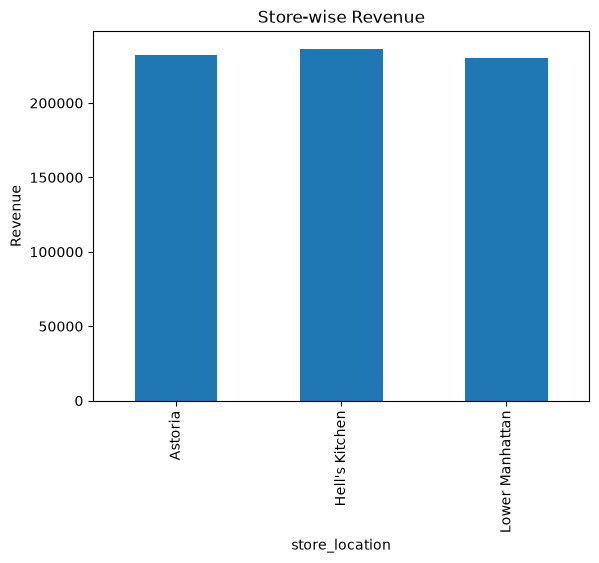

In [39]:
import matplotlib.pyplot as plt

store_revenue.plot(kind="bar")

plt.title("Store-wise Revenue")
plt.ylabel("Revenue")
plt.show()

In [40]:
df["revenue"] = df["transaction_qty"] * df["unit_price"]
df.head()

print("Total Revenue:", df["revenue"].sum())
print("Total Transactions:", len(df))
print("Total Stores:", df["store_location"].nunique())

Total Revenue: 698812.3300000001
Total Transactions: 149116
Total Stores: 3


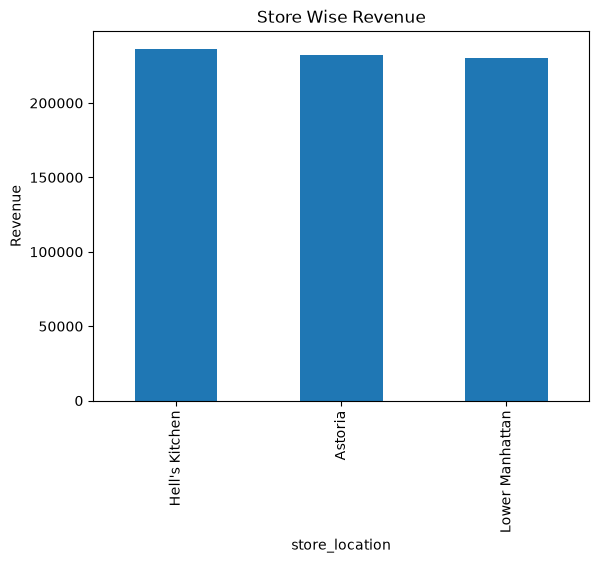

In [41]:
store_revenue = (
    df.groupby("store_location")["revenue"]
    .sum()
    .sort_values(ascending=False)
)
store_revenue

import matplotlib.pyplot as plt

store_revenue.plot(kind="bar")
plt.title("Store Wise Revenue")
plt.ylabel("Revenue")
plt.show()

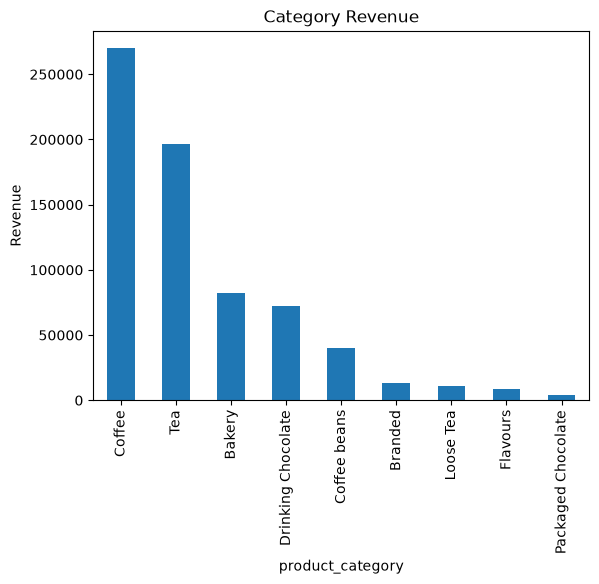

In [42]:
category_revenue = (
    df.groupby("product_category")["revenue"]
    .sum()
    .sort_values(ascending=False)
)

category_revenue

category_revenue.plot(kind="bar")
plt.title("Category Revenue")
plt.ylabel("Revenue")
plt.show()

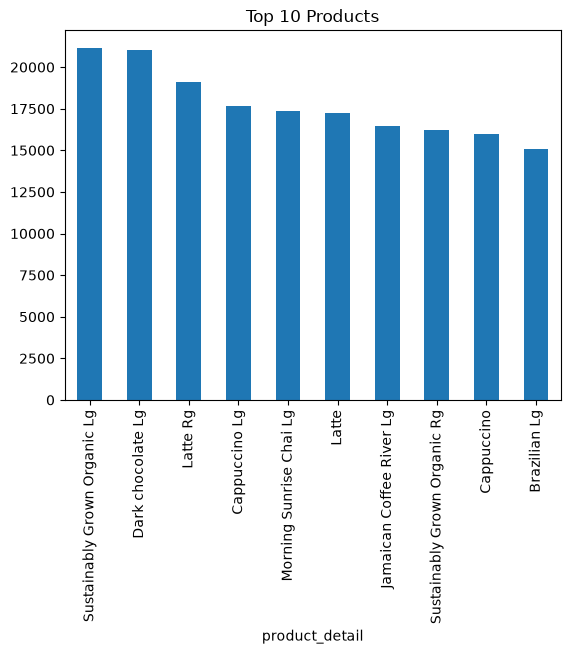

In [43]:
top_products = (df.groupby("product_detail")["revenue"].sum().sort_values(ascending=False).head(10))
top_products
top_products.plot(kind="bar")
plt.title("Top 10 Products")
plt.show()

In [44]:
df["transaction_time"].head()
type(df["transaction_time"][0])

datetime.time

In [45]:
df["hour"] = df["transaction_time"].apply(lambda x: x.hour)

In [46]:
df[["transaction_time","hour"]].head()

,transaction_time,hour
0,07:06:11,7
1,07:08:56,7
2,07:14:04,7
3,07:20:24,7
4,07:22:41,7


In [47]:
hourly_sales = (
    df.groupby("hour")["revenue"]
    .sum()
)

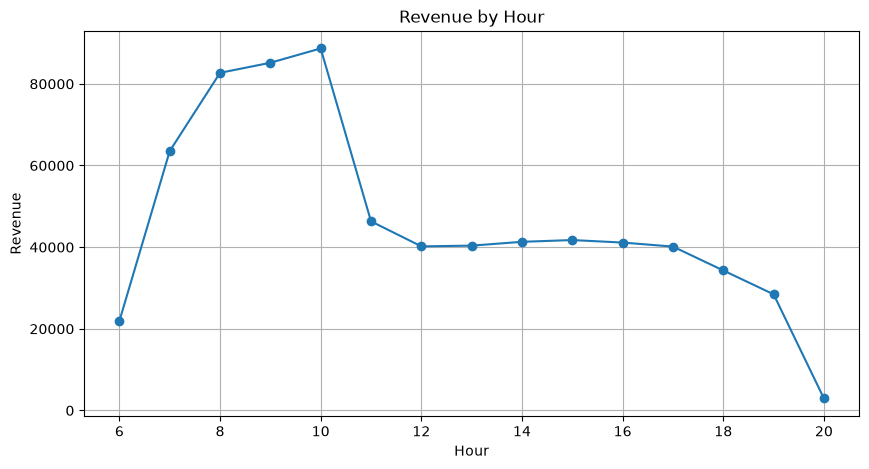

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

hourly_sales.plot(marker='o')

plt.title("Revenue by Hour")
plt.xlabel("Hour")
plt.ylabel("Revenue")

plt.grid(True)

plt.show()

In [49]:
# Peak Demand Detection

threshold = df["transaction_qty"].quantile(0.90)

print("Peak Threshold:", threshold)

df["peak_demand"] = (
    df["transaction_qty"] >= threshold
).astype(int)

df["peak_demand"].value_counts()

Peak Threshold: 2.0


peak_demand
0    87159
1    61957
Name: count, dtype: int64

In [50]:
features = [
    "hour",
    "unit_price",
    "store_id",
    "product_id"
]

X = df[features]

y = df["peak_demand"]

In [51]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [52]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [53]:
y_pred = model.predict(X_test)

In [54]:
from sklearn.metrics import (
    accuracy_score,
    classification_report
)

print("Accuracy:",
      accuracy_score(y_test, y_pred))

print(classification_report(
    y_test,
    y_pred
))

Accuracy: 0.6393843884120172
              precision    recall  f1-score   support

           0       0.70      0.69      0.69     17532
           1       0.56      0.57      0.57     12292

    accuracy                           0.64     29824
   macro avg       0.63      0.63      0.63     29824
weighted avg       0.64      0.64      0.64     29824



In [55]:
print(df.columns)

excel_file = pd.ExcelFile(
    "Afficionado Coffee Roasters.xlsx"
)

print(excel_file.sheet_names)

Index(['transaction_id', 'year', 'transaction_time', 'transaction_qty',
       'store_id', 'store_location', 'product_id', 'unit_price',
       'product_category', 'product_type', 'product_detail', 'revenue', 'hour',
       'peak_demand'],
      dtype='str')
['Transactions']


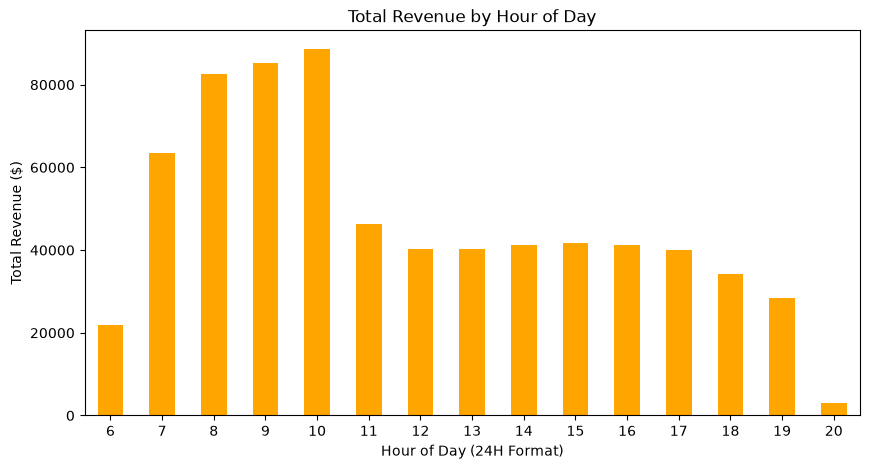

In [56]:
# Extract the hour from the transaction_time column
df['hour'] = df['transaction_time'].astype(str).str.split(':').str[0].astype(int)

# Group by hour to see total revenue and number of transactions
hourly_revenue = df.groupby('hour')['revenue'].sum()
hourly_transactions = df.groupby('hour')['transaction_id'].count()

# Plotting Hourly Revenue
plt.figure(figsize=(10, 5))
hourly_revenue.plot(kind='bar', color='orange')
plt.title("Total Revenue by Hour of Day")
plt.xlabel("Hour of Day (24H Format)")
plt.ylabel("Total Revenue ($)")
plt.xticks(rotation=0)
plt.show()

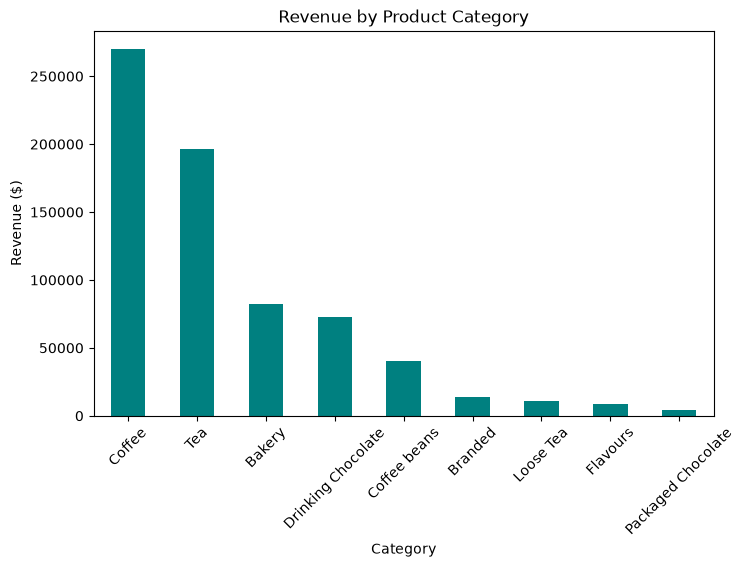

In [57]:
# Calculate revenue by product category
category_revenue = df.groupby("product_category")["revenue"].sum().sort_values(ascending=False)

# Plotting Category Revenue
plt.figure(figsize=(8, 5))
category_revenue.plot(kind='bar', color='teal')
plt.title("Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=45)
plt.show()

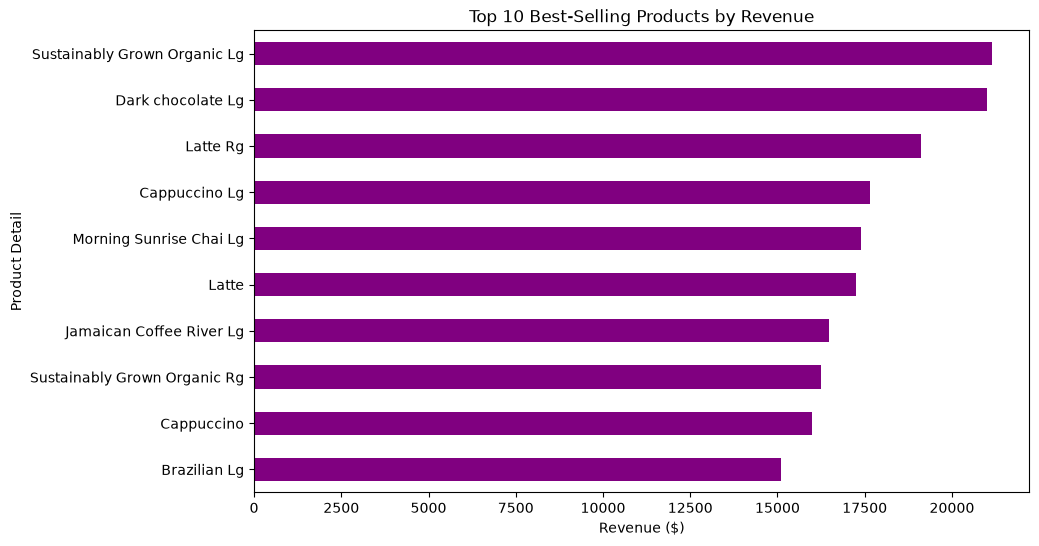

In [58]:
# Find the top 10 products by total revenue
top_10_products = df.groupby("product_detail")["revenue"].sum().sort_values(ascending=False).head(10)

# Plotting Top 10 Products
plt.figure(figsize=(10, 6))
top_10_products.plot(kind='barh', color='purple')
plt.title("Top 10 Best-Selling Products by Revenue")
plt.xlabel("Revenue ($)")
plt.ylabel("Product Detail")
plt.gca().invert_yaxis() # Highest seller at the top
plt.show()

In [59]:
# ## Executive Summary & Business Insights
# 1. **Store Performance:** (Insert your observation here, e.g., Hell's Kitchen generated the highest overall revenue).
# 2. **Peak Operations:** (Insert the busiest hours you found in step 1. Suggest adding more staff during these hours).
# 3. **Product Strategy:** (Insert the top-selling category and exact item. Suggest marketing these heavily or ensuring they are never out of stock).

In [60]:

print("=== Phase 3: Dynamic Datetime Reconstruction & Aggregation ===")
print("\n=== Dataset Limitation & Assumptions ===")

print("""Original dataset does not contain a transaction date field.
A continuous chronological timeline is reconstructed
by detecting transaction-time rollovers.

This reconstructed timeline is used only for
time-series modelling and demand forecasting.

Forecasts represent demand behaviour patterns
rather than exact calendar-date predictions.
""")

# 1. Load the dataset from Excel
df = pd.read_excel("Afficionado Coffee Roasters.xlsx", sheet_name='Transactions')

# 2. Convert transaction time to time offsets
df['time_parsed'] = pd.to_timedelta(df['transaction_time'].astype(str))

# 3. Detect when a new day rolls over (whenever time drops backwards chronologically)
df['time_diff'] = df['time_parsed'].diff()
day_indicators = (df['time_diff'] < pd.Timedelta(0)).astype(int)
df['day_offset'] = day_indicators.cumsum()

# 4. Map the offsets to a calendar starting Jan 1, 2025, to build a true continuous DatetimeIndex
df['date_parsed'] = pd.to_datetime('2025-01-01') + pd.to_timedelta(df['day_offset'], unit='D')
df['datetime'] = df['date_parsed'] + df['time_parsed']
print("\nTimeline Validation")

print("Start Date :", df['datetime'].min())
print("End Date   :", df['datetime'].max())

print("Total Days :", df['day_offset'].max() + 1)

# Calculate total revenue per transaction row
df['total_revenue'] = df['transaction_qty'] * df['unit_price']

# 5. Set the index for resampling
df.set_index('datetime', inplace=True)
print("✓ Chronological datetimes successfully reconstructed across 181 days.")

# -------------------------------------------------------------------------
# STEP 1: HOURLY TIME-SERIES CONSTRUCTION (Target 1: Volume)
# -------------------------------------------------------------------------
print("\nConstructing Hourly Dataset...")

hourly_df = df.groupby('store_id').resample('h').agg({
    'transaction_id': 'count',       # Target 1: Hourly transaction volume
    'transaction_qty': 'sum',        # Quantity tracking
    'total_revenue': 'sum'           # Financial tracking
}).rename(columns={'transaction_id': 'hourly_transaction_volume'}).reset_index()

# Fill empty/overnight hours with zero activity
hourly_df.fillna({'hourly_transaction_volume': 0, 'transaction_qty': 0, 'total_revenue': 0}, inplace=True)

# -------------------------------------------------------------------------
# STEP 2: DAILY TIME-SERIES CONSTRUCTION (Target 2: Revenue)
# -------------------------------------------------------------------------
print("Constructing Daily Dataset...")

daily_df = df.groupby('store_id').resample('D').agg({
    'transaction_qty': 'sum',
    'total_revenue': 'sum'           # Target 2: Daily revenue per store
}).rename(columns={'total_revenue': 'daily_revenue'}).reset_index()

# Fill empty days with zero activity
daily_df.fillna({'transaction_qty': 0, 'daily_revenue': 0}, inplace=True)

print("\n=== Data Aggregation Complete ===")
print(f"Hourly DataFrame Shape: {hourly_df.shape} rows")
print(f"Daily DataFrame Shape: {daily_df.shape} rows\n")

print("Hourly Time-Series Baseline Sample:")
print(hourly_df.head(5))

=== Phase 3: Dynamic Datetime Reconstruction & Aggregation ===

=== Dataset Limitation & Assumptions ===
Original dataset does not contain a transaction date field.
A continuous chronological timeline is reconstructed
by detecting transaction-time rollovers.

This reconstructed timeline is used only for
time-series modelling and demand forecasting.

Forecasts represent demand behaviour patterns
rather than exact calendar-date predictions.


Timeline Validation
Start Date : 2025-01-01 07:06:11
End Date   : 2025-06-30 20:57:19
Total Days : 181
✓ Chronological datetimes successfully reconstructed across 181 days.

Constructing Hourly Dataset...
Constructing Daily Dataset...

=== Data Aggregation Complete ===
Hourly DataFrame Shape: (12996, 5) rows
Daily DataFrame Shape: (543, 4) rows

Hourly Time-Series Baseline Sample:
   store_id            datetime  hourly_transaction_volume  transaction_qty  \
0         3 2025-01-01 11:00:00                         22               31   
1         3 2

In [61]:

print("=== Phase 4: Feature Engineering ===")

# -------------------------------------------------------------------------
# STEP 1: HOURLY FEATURES (For Transaction Volume Forecasting)
# -------------------------------------------------------------------------
print("Engineering Hourly Features...")

# Sort to guarantee exact timeline order per store
hourly_df = hourly_df.sort_values(by=['store_id', 'datetime']).reset_index(drop=True)

# Generate Lags (Shifted per store group)
hourly_df['lag_1h'] = hourly_df.groupby('store_id')['hourly_transaction_volume'].shift(1)  # Previous hour
hourly_df['lag_24h'] = hourly_df.groupby('store_id')['hourly_transaction_volume'].shift(24) # Same hour yesterday

# Generate Rolling Metrics (Average of last 3 hours of operation)
hourly_df['rolling_mean_3h'] = hourly_df.groupby('store_id')['hourly_transaction_volume'].transform(lambda x: x.shift(1).rolling(3).mean())

# Extract Time Indicators
hourly_df['hour_of_day'] = hourly_df['datetime'].dt.hour
hourly_df['day_of_week'] = hourly_df['datetime'].dt.dayofweek
hourly_df['is_weekend'] = hourly_df['day_of_week'].isin([5, 6]).astype(int)

# -------------------------------------------------------------------------
# STEP 2: DAILY FEATURES (For Store Revenue Forecasting)
# -------------------------------------------------------------------------
print("Engineering Daily Features...")

# Sort to guarantee exact timeline order per store
daily_df = daily_df.sort_values(by=['store_id', 'datetime']).reset_index(drop=True)

# Generate Lags
daily_df['lag_1d'] = daily_df.groupby('store_id')['daily_revenue'].shift(1) # Yesterday's revenue
daily_df['lag_7d'] = daily_df.groupby('store_id')['daily_revenue'].shift(7) # Revenue same day last week

# Generate Rolling Metrics (7-day momentum)
daily_df['rolling_mean_7d'] = daily_df.groupby('store_id')['daily_revenue'].transform(lambda x: x.shift(1).rolling(7).mean())

# Extract Calendar Metrics
daily_df['day_of_week'] = daily_df['datetime'].dt.dayofweek
daily_df['day_of_month'] = daily_df['datetime'].dt.day
daily_df['is_weekend'] = daily_df['day_of_week'].isin([5, 6]).astype(int)

# -------------------------------------------------------------------------
# STEP 3: DROP BROKEN ROWS
# -------------------------------------------------------------------------
# Shifting values leaves 'NaN' rows at the very beginning of our calendar
# (e.g., the first hour doesn't have a t-24 yesterday lag). We safely drop them.
hourly_df.dropna(inplace=True)
daily_df.dropna(inplace=True)

print("\n=== Feature Engineering Complete ===")
print(f"Hourly Model Matrix Shape: {hourly_df.shape}")
print(f"Daily Model Matrix Shape: {daily_df.shape}\n")
print("Engineered Hourly Matrix Snapshot:")
print(hourly_df[['datetime', 'store_id', 'hourly_transaction_volume', 'lag_1h', 'lag_24h', 'hour_of_day']].head(3))

=== Phase 4: Feature Engineering ===
Engineering Hourly Features...
Engineering Daily Features...

=== Feature Engineering Complete ===
Hourly Model Matrix Shape: (12924, 11)
Daily Model Matrix Shape: (522, 10)

Engineered Hourly Matrix Snapshot:
              datetime  store_id  hourly_transaction_volume  lag_1h  lag_24h  \
24 2025-01-02 11:00:00         3                         26     0.0     22.0   
25 2025-01-02 12:00:00         3                         26    26.0     27.0   
26 2025-01-02 13:00:00         3                         23    26.0     19.0   

    hour_of_day  
24           11  
25           12  
26           13  


In [ ]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import (mean_absolute_error,mean_squared_error,mean_absolute_percentage_error)

print("=== Phase 5: Time-Based Split & Model Training ===")

# -------------------------------------------------------------------------
# STEP 1: DEFINE TIME-SPLIT (Train: Jan-May, Test: June 2025)
# -------------------------------------------------------------------------
split_date = '2025-06-01'

# --- Hourly Model Setup ---
hourly_train = hourly_df[hourly_df['datetime'] < split_date]
hourly_test = hourly_df[hourly_df['datetime'] >= split_date]

hourly_features = ['store_id', 'lag_1h', 'lag_24h', 'rolling_mean_3h', 'hour_of_day', 'day_of_week', 'is_weekend']
X_train_h = hourly_train[hourly_features]
y_train_h = hourly_train['hourly_transaction_volume']
X_test_h = hourly_test[hourly_features]
y_test_h = hourly_test['hourly_transaction_volume']

# --- Daily Model Setup ---
daily_train = daily_df[daily_df['datetime'] < split_date]
daily_test = daily_df[daily_df['datetime'] >= split_date]

daily_features = ['store_id', 'lag_1d', 'lag_7d', 'rolling_mean_7d', 'day_of_week', 'day_of_month', 'is_weekend']
X_train_d = daily_train[daily_features]
y_train_d = daily_train['daily_revenue']
X_test_d = daily_test[daily_features]
y_test_d = daily_test['daily_revenue']

# -------------------------------------------------------------------------
# STEP 2: TRAIN AND EVALUATE MODEL 1 (HOURLY TRANSACTION VOLUME)
# -------------------------------------------------------------------------
naive_predictions = X_test_h['lag_1h']

naive_mae = mean_absolute_error(
    y_test_h,
    naive_predictions
)

naive_rmse = np.sqrt(mean_squared_error(y_test_h,naive_predictions))

print("\nNaive Forecast Benchmark")
print("MAE:", naive_mae)
print("RMSE:", naive_rmse)

print("\nTraining Hourly Volume Predictor (XGBoost)...")
model_hourly = XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=5, random_state=42)
model_hourly.fit(X_train_h, y_train_h)

# Predict & Evaluate
hourly_test = hourly_test.copy()
hourly_test['predictions'] = model_hourly.predict(X_test_h)

mae_h = mean_absolute_error(
    y_test_h,
    hourly_test['predictions']
)

rmse_h = np.sqrt(
    mean_squared_error(
        y_test_h,
        hourly_test['predictions']
    )
)

# Calculate Hourly MAPE safely
actual_h = np.asarray(y_test_h)
predicted_h = np.asarray(hourly_test["predictions"])

mask_h = actual_h != 0

if mask_h.any():
    mape_h = (
        np.mean(
            np.abs(
                (actual_h[mask_h] - predicted_h[mask_h])
                / actual_h[mask_h]
            )
        ) * 100
    )
else:
    mape_h = 0.0

print(f"Hourly MAPE: {mape_h:.2f}%")

print(f"Hourly Model Metrics -> MAE: {mae_h:.2f} transactions, RMSE: {rmse_h:.2f}")
comparison = pd.DataFrame({
    'Model':['Naive','XGBoost'],
    'MAE':[naive_mae,mae_h],
    'RMSE':[naive_rmse,rmse_h]
})

print("\nModel Comparison")
print(comparison)

# -------------------------------------------------------------------------
# STEP 3: TRAIN AND EVALUATE MODEL 2 (DAILY REVENUE)
# -------------------------------------------------------------------------
print("\nTraining Daily Revenue Predictor (XGBoost)...")
model_daily = XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=5, random_state=42)
model_daily.fit(X_train_d, y_train_d)

# Predict & Evaluate
daily_test = daily_test.copy()
daily_test['predictions'] = model_daily.predict(X_test_d)

mae_d = mean_absolute_error(y_test_d, daily_test['predictions'])
rmse_d = np.sqrt(mean_squared_error(y_test_d, daily_test['predictions']))
mape_d = mean_absolute_percentage_error(
    y_test_d,
    daily_test['predictions']
) * 100

print(f"Daily MAPE: {mape_d:.2f}%")

print(f"Daily Model Metrics  -> MAE: ${mae_d:.2f}, RMSE: ${rmse_d:.2f}")
forecast_accuracy = 100 - mape_d

print(
    f"\nForecast Accuracy: "
    f"{forecast_accuracy:.2f}%"
)

plt.figure(figsize=(15,5))

plt.plot(
    daily_test['datetime'],
    y_test_d,
    label='Actual Revenue'
)

plt.plot(
    daily_test['datetime'],
    daily_test['predictions'],
    label='Predicted Revenue'
)

plt.title("Actual vs Predicted Daily Revenue")

plt.legend()
plt.grid(True)

plt.show()


plt.figure(figsize=(15,5))

plt.plot(
    hourly_test['datetime'],
    y_test_h,
    label='Actual Volume'
)

plt.plot(
    hourly_test['datetime'],
    hourly_test['predictions'],
    label='Predicted Volume'
)

plt.title("Actual vs Predicted Hourly Transactions")

plt.legend()
plt.grid(True)

plt.show()



importance_df = pd.DataFrame({
    'Feature': hourly_features,
    'Importance': model_hourly.feature_importances_
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

print("\nFeature Importance")
print(importance_df)

plt.figure(figsize=(8,5))

plt.barh(
    importance_df['Feature'],
    importance_df['Importance']
)

plt.title("Feature Importance - Hourly Model")

plt.show()


store_forecast = (
    hourly_test
    .groupby('store_id')
    .agg({
        'hourly_transaction_volume':'sum',
        'predictions':'sum'
    })
)

print("\nStore-wise Forecast")

print(store_forecast)

peak_actual = y_test_h.quantile(0.90)

actual_peaks = (
    y_test_h >= peak_actual
)

predicted_peaks = (
    hourly_test['predictions'] >= peak_actual
)

peak_capture_rate = (
    predicted_peaks[actual_peaks]
    .sum()
    /
    actual_peaks.sum()
) * 100

print(
    f"\nPeak Demand Capture Rate: "
    f"{peak_capture_rate:.2f}%"
)

# -------------------------------------------------------------------------
# STEP 4: EXPORT MODELS FOR STREAMLIT INTERFACE
# -------------------------------------------------------------------------
import pickle
with open('model_hourly.pkl', 'wb') as f:
    pickle.dump(model_hourly, f)
with open('model_daily.pkl', 'wb') as f:
    pickle.dump(model_daily, f)
# Save model metrics for Streamlit
import json

metrics = {
    "hourly_mae": float(mae_h),
    "hourly_rmse": float(rmse_h),
    "hourly_mape": float(mape_h),
    "daily_mae": float(mae_d),
    "daily_rmse": float(rmse_d),
    "daily_mape": float(mape_d),
    "forecast_accuracy": float(forecast_accuracy),
    "peak_capture_rate": float(peak_capture_rate)
}

with open("metrics.json", "w") as f:
    json.dump(metrics, f, indent=4)

print("\n✓ metrics.json updated successfully")
print("\n✓ Saved production model artifacts: 'model_hourly.pkl' and 'model_daily.pkl'")
print("\n=== Business Recommendations ===")

print("""
1. Increase staffing during morning rush hours.

2. Maintain higher inventory levels
   for top-selling products.

3. Use store-specific forecasts
   for inventory planning.

4. Allocate resources differently
   across locations.

5. Use forecast outputs to reduce
   stock-outs and inventory waste.
""")

=== Phase 5: Time-Based Split & Model Training ===


NameError: name 'hourly_df' is not defined